## Artéfact à la YASA

In [ ]:
import yasa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='white', font_scale=1.2)
import mne
import io


In [ ]:

raw = mne.io.read_raw_edf('D:/EEG/raw/MN143/MN143_240115E-A.edf', preload=True)
data = raw.get_data()
chan = raw.ch_names
sfreq = raw.info['sfreq'] 

hypno_path = 'D:/EEG/raw/MN143/MN143_240115E-AhypnoEXP.txt'
hypno_df = pd.read_csv(hypno_path, sep="\t", names=["start", "time", "stage", "code"])

# Convertir les stades texte en code YASA
stage_map = {
    "W": 0, "N1": 1, "N2": 2, "N3": 3, "REM": 4
}

print(f"{data.shape[0]} canaux, {data.shape[1]} points à {sfreq} Hz")
chan
(data*10**6).round(4)

In [ ]:
# Plot hypnogram and spectrogram on Fz
# We should see a warning because of the flat data at the end
sf = 100.
hypno_int = hypno_df["stage"].str.strip().map(stage_map).fillna(-2).astype(int)
hypno_vec = yasa.hypno_upsample_to_data(hypno_int.values, 1/30, data[2], sf)
fig = yasa.plot_spectrogram(data[2], sf, hypno=hypno_vec)

# Récupère les axes de la figure
ax0, ax1 = fig.axes  # ax0 = hypnogram, ax1 = spectrogramme

# Limite d'heure
ax0.set_xlim(0, 8)
ax1.set_xlim(0, 8)

plt.tight_layout()
plt.show()

Attention, on remarque que pour beaucoup, on obtiens le message warning.

Je pense que pour exploiter au mieux l'outils, il faudrait un hypnogramme aussi long que le spectogramme (.edf)

## C'est parti

In [ ]:
art, zscores = yasa.art_detect(data, sf, window=5, method='covar', threshold=3)
art.shape, zscores.shape

In [ ]:
# Art is an aray of 0 and 1, where 0 indicates a clean (or good epoch)  and 1 indicates an artifact epoch
print(art)
print(f'{art.sum()} / {art.size} epochs rejected.')

In [ ]:
# Plot the artifact vector
plt.plot(art);
plt.yticks([0, 1], labels=['Good (0)', 'Art (1)']);

In [ ]:
sns.histplot(zscores, stat='density', alpha=0.4, edgecolor=(1, 1, 1, 0.4), kde=True, kde_kws=dict(cut=3))
plt.title('Histogram of z-scores')
plt.xlabel('Z-scores')
plt.ylabel('Density')
plt.axvline(3, color='r', label='Threshold')
plt.axvline(-3, color='r')
plt.legend(frameon=False);

In [ ]:

from scipy.special import erf
threshold = 3
perc_expected_rejected = (1 - erf(threshold / np.sqrt(2))) * 100
print(f'{perc_expected_rejected:.2f}% of all epochs are expected to be rejected.')

In [ ]:
# Actual
(art.sum() / art.size) * 100
print(f'{(art.sum() / art.size) * 100:.2f}% of all epochs were actually rejected.')

In [ ]:
# Merge the artifcat vector with the hypnogram
# The resolution of art is 5 seconds, so its sampling frequency is 1/5 (= 0.2 Hz)
sf_art = 1 / 5
art_up = yasa.hypno_upsample_to_data(art, sf_art, data, sf)
art_up.shape, hypno_vec.shape

Now that hypno and art_up have the same size, we can easily merge them. Below, we mark as artifact (code = -1) all the 5-seconds epochs that were automatically rejected:

In [ ]:
# Add -1 to hypnogram where artifacts were detected
hypno_with_art = hypno_vec.copy()
hypno_with_art[art_up] = -1

# Proportion of each stage in ``hypno_with_art``
pd.Series(hypno_with_art).value_counts(normalize=True)

In [ ]:
# Plot new hypnogram and spectrogram on Fz
fig = yasa.plot_spectrogram(data[2], sf, hypno=hypno_with_art)

# Récupère les axes de la figure
ax0, ax1 = fig.axes  # ax0 = hypnogram, ax1 = spectrogramme

# Limite d'heure
ax0.set_xlim(0, 8)
ax1.set_xlim(0, 8)

plt.tight_layout()
plt.show()

 ## The Riemannian Potato Field method:

 - https://hal.archives-ouvertes.fr/hal-00781701/
- https://doi.org/10.1109/TNSRE.2019.2893113

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from mne import make_fixed_length_epochs
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.io import read_raw_edf
import numpy as np

from pyriemann.clustering import Potato, PotatoField
from pyriemann.estimation import Covariances
from pyriemann.utils.covariance import normalize
from pyriemann.utils.distance import distance_riemann
from pyriemann.utils.mean import mean_riemann

In [ ]:
def filter_bandpass(signal, low_freq, high_freq, channels=None, method="iir"):
    """Filter signal on specific channels and in a specific frequency band"""
    sig = signal.copy()
    if channels is not None:
        sig.pick_channels(channels)
    sig.filter(l_freq=low_freq, h_freq=high_freq, method=method, verbose=False)
    return sig

def regularize_covs(covs, reg=1e-5):
    return np.array([cov + reg * np.eye(cov.shape[-1]) for cov in covs])

def plot_detection(ax, rp_label, rpf_label):
    labels = []
    ylims = ax.get_ylim()
    height = ylims[1] - ylims[0]
    if not rp_label:
        r1 = ax.axhspan(
            ylims[0] + 0.06 * height, ylims[1] - 0.05 * height,
            edgecolor="r", facecolor="none",
            xmin=-test_time_start / test_duration - 0.005,
            xmax=(duration - test_time_start) / test_duration - 0.005)
        labels.append(r1)
        ax.text(0.25, 0.95, "RP", color="r", size=16, transform=ax.transAxes)
    if not rpf_label:
        r2 = ax.axhspan(
            ylims[0] + 0.05 * height, ylims[1] - 0.06 * height,
            edgecolor="m", facecolor="none",
            xmin=-test_time_start / test_duration + 0.005,
            xmax=(duration - test_time_start) / test_duration + 0.005)
        labels.append(r2)
        ax.text(0.65, 0.95, "RPF", color="m", size=16, transform=ax.transAxes)
    if rp_label and rpf_label:
        r3 = ax.axhspan(
            ylims[0] + 0.05 * height, ylims[1] - 0.05 * height,
            edgecolor="k", facecolor="none",
            xmin=-test_time_start / test_duration,
            xmax=(duration - test_time_start) / test_duration)
        labels.append(r3)
    return labels

In [ ]:
# Load motor imagery data
raw = read_raw_edf("D:/EEG/raw/MN143/MN143_240115E-A.edf")
raw.load_data()
sfreq = int(raw.info["sfreq"])  

# Select the channels 
print(f"Liste des canaux:",raw.ch_names)
raw.pick_channels(
    ['EEG Fp1', 'EEG Fp2', 'EEG C3', 'EEG C4', 'EEG T3',
       'EEG T4', 'EEG O1', 'EEG O2', 'EOGD', 'EOGG', 'EEG A1',
         'Menton', 'JAMBG','JAMBD', 'EMG2', 'EMG1'], ordered=True)
ch_names = raw.ch_names
ch_count = len(ch_names)

# Define time-series epoching with a sliding window
duration = 2.5    # duration of epochs
interval = 0.2    # interval between epochs

In [ ]:
# RP definition
z_th = 3.0           # z-score threshold
low_freq, high_freq = 1., 35.
rp = Potato(metric="riemann", threshold=z_th)

# EEG processing for RP
rp_sig = filter_bandpass(raw, low_freq, high_freq)  # band-pass filter
rp_epochs = make_fixed_length_epochs(  # epoch time-series
    rp_sig, duration=duration, overlap=duration - interval, verbose=False
).get_data(copy=False)
rp_covs = Covariances(estimator="scm").transform(rp_epochs)
rp_covs = regularize_covs(rp_covs)

# RP training
train_covs = 45      # nb of matrices for training
train_set = range(train_covs)
rp.fit(rp_covs[train_set])

In [ ]:
# RPF definition
z_th = 3.0 
p_th = 0.01          # probability threshold
rpf_config = {
    "RPF eye_blinks": {  # for eye-blinks
        "ch_names": ["EEG Fp1", "EEG Fp2"],
        "low_freq": 1.,
        "high_freq": 20.},
    "RPF occipital": {  # for high-frequency artifacts in occipital area
        "ch_names": ["EOGD", "EOGG"],
        "low_freq": 25.,
        "high_freq": 45.,
        "cov_normalization": "trace"},  # trace-norm to be insensitive to power
    "RPF global_lf": {  # for low-frequency artifacts in all channels
        "ch_names": None,
        "low_freq": 0.5,
        "high_freq": 3.}
}
rpf_covs = []
valid_potatoes = []

for i, p in enumerate(rpf_config.values()):
    print(f"Traitement de la Potato {i+1}")

    rpf_sig = filter_bandpass(raw, p.get("low_freq"), p.get("high_freq"),
                              channels=p.get("ch_names"))
    rpf_epochs = make_fixed_length_epochs(
        rpf_sig, duration=duration, overlap=duration - interval, verbose=False
    ).get_data(copy=False)

    covs_ = Covariances(estimator="scm").transform(rpf_epochs)

    # Supprimer les matrices trop petites ou nulles
    covs_ = covs_[np.linalg.norm(covs_, axis=(1, 2)) > 1e-12]

    if p.get("cov_normalization"):
        try:
            covs_ = normalize(covs_, p.get("cov_normalization"))
        except Exception as e:
            print(f"  Échec normalisation : {e}")
            continue

    covs_ = regularize_covs(covs_)

    # Nettoyage des NaN / Inf
    is_valid = np.all(np.isfinite(covs_), axis=(1, 2))
    covs_ = covs_[is_valid]

    if len(covs_) < 5:
        print(f"  Pas assez de matrices valides, potato ignorée")
        continue

    try:
        m = mean_riemann(covs_)
        d = [distance_riemann(c, m) for c in covs_]
        print(f"  Distance moyenne = {np.mean(d):.3f} ± {np.std(d):.3f}")
    except Exception as e:
        print(f"  Échec du calcul de distance : {e}")
        continue

    rpf_covs.append(covs_)
    valid_potatoes.append(i)

# Création du PotatoField avec uniquement les potatoes valides
print(f"\nNombre de potatoes entraînées : {len(valid_potatoes)}")

rpf = PotatoField(metric="riemann", z_threshold=z_th, p_threshold=p_th,
                  n_potatoes=len(valid_potatoes))

# Entraînement
rpf.fit([c[train_set] for c in rpf_covs])


In [ ]:
# Prepare data for online detection
test_covs_max = 400     # nb of epochs to visualize in this example
test_covs_visu = 100    # nb of z-scores/proba to display simultaneously
test_time_start = -2    # start time to display signal
test_time_end = 5       # end time to display signal

test_duration = test_time_end - test_time_start
time_start = train_covs * interval + test_time_start
time_end = train_covs * interval + test_time_end
time = np.linspace(time_start, time_end, int((time_end - time_start) * sfreq),
                   endpoint=False)
raw.filter(l_freq=0.5, h_freq=75., method="iir", verbose=False)
eeg_data = 1e10 * raw.get_data()
sig = eeg_data[:, int(time_start * sfreq):int(time_end * sfreq)]
eeg_offset = - 15 * np.linspace(1, ch_count, ch_count, endpoint=False)
covs_t, covs_z = np.empty([0]), np.empty([len(rpf_config) + 1, 0])
covs_p = np.empty([0])

fig, ax = plt.subplots(figsize=(12, 10), nrows=2, ncols=1)
fig.suptitle("Online artifact detection, RP vs RPF", fontsize=16)
ax[0].set(xlabel="Time (s)", ylabel="EEG channels")
ax[0].set_xlim([time[0], time[-1]])
ax[0].set_yticks(eeg_offset)
ax[0].set_yticklabels(ch_names)
pl = ax[0].plot(time, sig.T + eeg_offset.T, lw=0.75)
labels = []

ax[1].set(xlabel="Time (s)", ylabel="Z-scores of distances to references")
pl2 = ax[1].plot(covs_t, covs_z.T, lw=0.75)
for c, l in enumerate(["RP"] + [*rpf_config]):
    pl2[c].set_label(l)
ax[1].set_ylim([-1.5, 8.5])
ax[1].legend(loc="upper left")
axp = ax[1].twinx()
axp.set(ylabel="RPF probability of clean EEG")
pl3 = axp.plot(covs_t, covs_p, lw=0.75, c="k", label="RPF proba")
axp.set_ylim([0, 1])
axp.legend(loc="upper right")

In [ ]:
def online_detect(t):
    global time, sig, labels, covs_t, covs_z, covs_p

    # Prédictions RP et RPF
    rp_label = rp.predict(rp_covs[np.newaxis, t])[0]
    rp_zscore = rp.transform(rp_covs[np.newaxis, t])

    rpf_cov_t = [c[np.newaxis, t] for c in rpf_covs]
    rpf_label = rpf.predict(rpf_cov_t)[0]
    rpf_zscores = rpf.transform(rpf_cov_t)
    rpf_proba = rpf.predict_proba(rpf_cov_t)

    # Mise à jour adaptative (si label = clean)
    if rp_label == 1:
        rp.partial_fit(rp_covs[np.newaxis, t], alpha=1 / (t + 1))
    if rpf_label == 1:
        rpf.partial_fit(rpf_cov_t, alpha=1 / (t + 1))

    # Mise à jour temporelle
    time_start = t * interval + test_time_end
    time_end = (t + 1) * interval + test_time_end
    time_ = np.linspace(time_start, time_end, int(interval * sfreq), endpoint=False)
    new_sig = eeg_data[:, int(time_start * sfreq):int(time_end * sfreq)]

    # Synchronisation exacte entre new_sig et time_
    if new_sig.shape[1] != len(time_):
        min_len = min(new_sig.shape[1], len(time_))
        new_sig = new_sig[:, :min_len]
        time_ = time_[:min_len]

    time = np.r_[time[int(interval * sfreq):], time_]
    sig = np.hstack((sig[:, int(interval * sfreq):], new_sig))

    # Mise à jour des z-scores et probabilités
    covs_t = np.r_[covs_t, time_start]

    rp_zscore = np.atleast_2d(rp_zscore)        # (1, 1)
    rpf_zscores = np.atleast_2d(rpf_zscores).T  # (n_potatoes, 1)
    covs_z_new = np.vstack((rp_zscore, rpf_zscores))  # (n_potatoes + 1, 1)

    if covs_z.shape[1] == 0:
        covs_z = covs_z_new
    else:
        covs_z = np.hstack((covs_z, covs_z_new))

    covs_p = np.r_[covs_p, rpf_proba]

    # Limitation de taille
    if len(covs_p) > test_covs_visu:
        covs_t = covs_t[1:]
        covs_z = covs_z[:, 1:]
        covs_p = covs_p[1:]

    # Harmonisation des longueurs (z-scores et probas)
    min_len_z = min(len(covs_t), covs_z.shape[1], len(covs_p))
    covs_t = covs_t[:min_len_z]
    covs_z = covs_z[:, :min_len_z]
    covs_p = covs_p[:min_len_z]

    # Harmonisation des longueurs (EEG)
    min_len_eeg = min(len(time), sig.shape[1])
    time = time[:min_len_eeg]
    sig = sig[:, :min_len_eeg]

    # Mise à jour des tracés EEG
    for c in range(ch_count):
        pl[c].set_data(time, sig[c] + eeg_offset[c])
        pl[c].axes.set_xlim(time[0], time[-1])

    for lbl in labels:
        lbl.remove()
    for txt in ax[0].texts:
        txt.set_visible(False)

    labels = plot_detection(ax[0], rp_label, rpf_label)

    # Mise à jour des z-scores
    for c in range(len(pl2)):
        pl2[c].set_data(covs_t, covs_z[c])
        pl2[c].axes.set_xlim(covs_t[0] - 0.1, covs_t[-1])

    # Mise à jour des probabilités
    pl3[0].set_data(covs_t, covs_p)

    return pl + pl2 + pl3


In [ ]:
# Affichage interactif de l'animation complète

# Animation HTML 
try:
    from IPython.display import HTML
    import warnings
    plt.rcParams["animation.embed_limit"] = 10
    plt.show()
    
    interval_display = 1500

    # Recréation de l'animation 
    start_frame = int(20 / interval)
    potato = FuncAnimation(fig, online_detect,
                        frames=range(start_frame, test_covs_max),
                        interval=interval_display,
                        blit=False, repeat=False)


    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        display(HTML(potato.to_jshtml(fps=5, default_mode="loop")))

except Exception as e:
    print("Erreur lors de l'affichage HTML de l'animation :", e)
   # print("Essai de sauvegarde de l'animation en .mp4...")

    # Sauvegarde fallback en .mp4
    #try:
        #from matplotlib.animation import FFMpegWriter
        #writer = FFMpegWriter(fps=5, metadata=dict(artist='RPF'), bitrate=1800)
        #potato.save("rpf_animation.mp4", writer=writer)
        #print("Animation sauvegardée dans le fichier : rpf_animation.mp4")
    #except Exception as err:
        #print("Échec de la sauvegarde vidéo :", err)


In [ ]:
print("EEG sample values:", eeg_data[:, :10])


In [ ]:
from mne import make_fixed_length_epochs
import numpy as np

def get_clean_epochs(raw, rpf, rpf_covs,
                     duration=2.5, interval=0.2, verbose=False):
    """
    Génère les époques EEG propres (non détectées comme artefacts par RP et RPF).

    Paramètres
    ----------
    raw : mne.io.Raw
        Signal EEG brut.
    rp : pyriemann.clustering.Potato
        Riemannian Potato entraînée.
    rpf : pyriemann.clustering.PotatoField
        Riemannian Potato Field entraînée.
    rp_covs : ndarray
        Matrices de covariance pour RP (shape : [n_epochs, n_chan, n_chan]).
    rpf_covs : list of ndarray
        Liste des matrices de covariance pour chaque Potato RPF.
    duration : float
        Durée d’une époque (en secondes).
    interval : float
        Décalage entre les époques (en secondes).
    verbose : bool
        Affiche un résumé.

    Retour
    ------
    clean_epochs : mne.Epochs
        Époques propres uniquement.
    """
    # Synchroniser la taille sur la plus petite
    min_len = min([c.shape[0] for c in rpf_covs] )
    rpf_covs = [c[:min_len] for c in rpf_covs]

    # Prédictions : 1 = propre, 0 = artefact
    rpf_labels = rpf.predict(rpf_covs)

    print("RPF :")
    print(f"  {np.sum(rpf_labels == 1)} propres / {len(rpf_labels)}")

    # Masque combiné
    clean_mask =(rpf_labels == 1)

    if verbose:
        n_total = len(rpf_labels)
        n_clean = np.sum(clean_mask)
        print(f"{n_clean}/{n_total} époques conservées ({100 * n_clean / n_total:.1f}%)")

    # Générer toutes les époques, puis filtrer
    epochs = make_fixed_length_epochs(
        raw, duration=duration, overlap=duration - interval, verbose=verbose
    )
    epochs = epochs[:min_len]

    return epochs[clean_mask]


In [ ]:
clean_epochs = get_clean_epochs(
    raw=raw,
    rpf=rpf,
    rpf_covs=rpf_covs,
    duration=2.5,
    interval=0.2,
    verbose=True
)


In [ ]:
clean_epochs



In [1]:
import os
import mne
import shutil
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
from pyriemann.utils.mean import mean_riemann
from pyriemann.utils.distance import distance_riemann

"""
EEG PREPROCESSING PIPELINE
==========================
Filtrage → Référence → ICA (FastICA | Picard) → (optionnel) Rejection by
Projection on the Riemannian manifold (RPF)

- Compatible gros fichiers (fenêtrage `tstep`, décimation temporaire)
- Picard multithreadé, FastICA mono‑thread (n_jobs retiré de scikit‑learn)
- RPF « memory‑safe » : traitement par batchs pour éviter les MemoryError

Version : 2025‑07‑11
"""

# =================================================
# 1. FILTRAGE & RÉFÉRENCEMENT
# =================================================

def preprocess_raw(raw, l_freq: float = 10, h_freq: float = 100, notch: float = 50, ref: str = "A1"):
    """Band‑pass 10‑100 Hz, notch 50 Hz, référence A1 ou average."""
    raw_f = raw.copy().filter(l_freq, h_freq, fir_design="firwin")
    raw_f.notch_filter(notch)
    if ref in raw_f.ch_names:
        raw_f.set_eeg_reference([ref])
    else:
        raw_f.set_eeg_reference("average", projection=False)
    return raw_f

# =================================================
# 2. ICA (FASTICA / PICARD)
# =================================================

def run_ica(
    raw: mne.io.BaseRaw,
    method: str = "fastica",
    n_comp: float | int = 0.99,
    random_state: int = 42,
    tstep: float = 30.0,
    resample_hz: float | None = None,
):
    """Retourne raw nettoyé + objet ICA.

    - method : 'fastica' ou 'picard'
    - n_comp : <1 → % variance, ≥1 → nb composantes
    - tstep : fenêtrage ICA pour RAM faible
    - resample_hz : décime temporairement pour speed‑up
    """
    if method not in {"fastica", "picard"}:
        raise ValueError("method doit être 'fastica' ou 'picard'")

    raw_fit = raw.copy()
    if resample_hz is not None and resample_hz < raw.info["sfreq"]:
        raw_fit = raw_fit.resample(resample_hz, npad="auto")

    fit_params: dict[str, object] = {}
    if method == "picard":
        fit_params = dict(ortho=False)  # + rapide, moins mémoire

    ica = ICA(method=method, n_components=n_comp, random_state=random_state, fit_params=fit_params)
    ica.fit(raw_fit, tstep=tstep)

    # Détection EOG/ECG
    eog_inds, ecg_inds = [], []
    eog_ch = next((c for c in raw.ch_names if "EOG" in c.upper()), None)
    if eog_ch:
        eog_inds, _ = ica.find_bads_eog(raw_fit, ch_name=eog_ch)
    ecg_ch = next((c for c in raw.ch_names if "ECG" in c.upper()), None)
    if ecg_ch:
        ecg_inds, _ = ica.find_bads_ecg(raw_fit, ch_name=ecg_ch)
    ica.exclude = eog_inds + ecg_inds

    raw_clean = ica.apply(raw.copy())
    return raw_clean, ica

# =================================================
# 3. SEGMENTATION FIXE
# =================================================

def segment_fixed_epochs(raw: mne.io.BaseRaw, dur: float = 4.0):
    events = mne.make_fixed_length_events(raw, 1, dur)
    epochs = mne.Epochs(raw, events, 1, 0, dur, baseline=None, preload=True)
    epochs._data = epochs.get_data().astype("float32")
    return epochs


# =================================================
# 4. RPF « MEMORY‑SAFE » PAR BATCHS
# =================================================

def _reg_cov(c, lam: float):
    return c + lam * np.eye(c.shape[-1], dtype=c.dtype)

def _epoch_cov(epoch_data: np.ndarray, lam: float):
    return _reg_cov(np.cov(epoch_data), lam)

def apply_rpf_batches(
    epochs: mne.Epochs,
    z: float = 2.0,
    lam: float = 1e-6,
    batch_size: int = 5000,
):
    """Rejection by Projection on the Riemannian manifold (RPF) en batchs.

    - batch_size : nb d'epochs chargées simultanément en RAM (≈5000 ⇒ ~200 Mo)
    """
    n_epochs = len(epochs)
    covs_list: list[np.ndarray] = []

    # 1) Calcul des covariances par batch (évite un gros tableau)
    for start in range(0, n_epochs, batch_size):
        stop = min(start + batch_size, n_epochs)
        data = epochs.get_data(start=start, stop=stop)  # shape (batch, ch, time)
        for ep in data:
            covs_list.append(_epoch_cov(ep, lam))
        del data  # libère RAM

    covs = np.stack(covs_list)  # (N, ch, ch) ~ taille réduite

    # 2) Barycentre Riemannien
    mu = mean_riemann(covs)

    # 3) Distances riemanniennes, toujours en batch
    dist = np.empty(n_epochs, dtype=np.float32)
    idx = 0
    for start in range(0, n_epochs, batch_size):
        stop = min(start + batch_size, n_epochs)
        for c in covs_list[start:stop]:
            dist[idx] = distance_riemann(c, mu)
            idx += 1

    thr = float(dist.mean() + z * dist.std())
    keep = dist < thr
    return epochs[keep], dist, thr

# =================================================
# 5. VISUALISATION RAPIDE
# =================================================

def quick_plot(raw0, raw_ica, epochs_rpf=None, n_ch: int = 5, dur: int = 10):
    sf = raw0.info["sfreq"]
    picks = mne.pick_types(raw0.info, eeg=True)[:n_ch]
    t = slice(0, int(dur * sf))
    rows = 3 if epochs_rpf is not None else 2
    fig, ax = plt.subplots(rows, 1, figsize=(12, 3 * rows), sharex=True)
    ax[0].set_title("Brut")
    ax[0].plot(raw0.get_data(picks)[:, t].T)
    ax[1].set_title("Après ICA")
    ax[1].plot(raw_ica.get_data(picks)[:, t].T)
    if epochs_rpf is not None:
        ax[2].set_title("Moyenne après RPF")
        ax[2].plot(epochs_rpf.get_data(picks).mean(0).T)
    ax[-1].set_xlabel("Samples")
    plt.tight_layout()
    plt.show()

# =================================================
# 6. EXEMPLE UTILISATION (main)
# =================================================

if __name__ == "__main__":
    # 0. Lecture
    raw = mne.io.read_raw_edf("D:/EEG/raw/MN143/MN143_240115E-A.edf", preload=True)

    # 1. Pré-traitement
    raw_p = preprocess_raw(raw)

    # 2. ICA (Picard → multithread)
    raw_ica, ica = run_ica(
        raw_p,
        method="picard",
        resample_hz=200,
        tstep=60.0,
    )

    # 3. RPF par batchs
    ep = segment_fixed_epochs(raw_ica, dur=4.0)
    ep_clean, d, thr = apply_rpf_batches(ep, batch_size=3000)

    # 4. Visualisation
    quick_plot(raw, raw_ica, ep_clean, n_ch=5, dur=10)


Extracting EDF parameters from D:\EEG\raw\MN143\MN143_240115E-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_19660\1167192527.py:170: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("D:/EEG/raw/MN143/MN143_240115E-A.edf", preload=True)


Reading 0 ... 6855679  =      0.000 ... 26779.996 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 10 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 10.00
- Lower transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 8.75 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 339 samples (1.324 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    3.7s
[Parallel(n_jobs=1)]: Done  33 out of  33 | elapsed:    6.7s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.7s
[Parallel(n_jobs=1)]: Done  33 out of  33 | elapsed:    5.1s finished


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 33 channels (please be patient, this may take a while)
Selecting by explained variance: 4 components
Fitting ICA took 256.3s.
Using EOG channel: EOGD
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed 

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Using threshold: 0.36 for CTPS ECG detection
Using channel ECG to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 2000 samples (10.000 s)

Number of ECG events detected : 53050 (average pulse 118.85735623599702 / min.)
Not setting metadata
53050 matching events found
No baseline correction applied
Using data from preloaded Raw for 53050 events and 201 original time points ...
1 bad epochs dropped
Applying ICA to Raw instance
    Transforming to ICA space (4 components)
    Zeroing out 0 ICA components
    Projecting back using 33 PCA components
Not setting met

TypeError: get_data() got an unexpected keyword argument 'start'

### On ré-essaye la YASA artefact detection

In [1]:
import mne 
import platform
import pandas as pd
from pathlib import Path
import yasa
import numpy as np



In [2]:

system = platform.system()
if system == "Darwin":
    disque = "/Volumes/Crucial X6"
elif system == "Windows":
    disque = "D:"
elif system == "Linux":
    disque = "/media/darryld/Crucial X6"
else:
    raise RuntimeError("Système non supporté.")

# == Preparation des variables ==
raw = mne.io.read_raw_edf(f'{disque}/EEG/raw/MN143/MN143_raw.edf', preload=True)
data = raw.get_data()
chan = raw.ch_names
sfreq = raw.info['sfreq'] 

hypno_path = Path(f'{disque}/EEG/raw/MN143/MN143_hypnoEXP.txt')
hypno_df = pd.read_csv(hypno_path, sep="\t", names=["start", "time", "stage", "code"])

# Convertir les stades texte en code YASA
hypno_df["stage"] = hypno_df["stage"].astype(str).str.strip().str.upper()

# Mapping YASA
stage_map = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "REM": 4
}

# Appliquer la correspondance
hypno_df["YASA_code"] = hypno_df["stage"].map(stage_map)

# == Vérification des résultats ==
print(hypno_df[["stage", "YASA_code"]].drop_duplicates())


print(f"{data.shape[0]} canaux, {data.shape[1]} points à {sfreq} Hz")

Extracting EDF parameters from /media/darryld/Crucial X6/EEG/raw/MN143/MN143_raw.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6855679  =      0.000 ... 26779.996 secs...


/tmp/ipykernel_3739/3849338190.py:12: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(f'{disque}/EEG/raw/MN143/MN143_raw.edf', preload=True)


    stage  YASA_code
0       W          0
121    N1          1
122    N2          2
151    N3          3
450   REM          4
33 canaux, 6855680 points à 256.0 Hz


In [3]:
hypno_df

,start,time,stage,code,YASA_code
0,30,00:00:30,W,1,0
1,60,00:01:00,W,1,0
2,90,00:01:30,W,1,0
3,120,00:02:00,W,1,0
4,150,00:02:30,W,1,0
...,...,...,...,...,...
887,26640,07:24:00,W,1,0
888,26670,07:24:30,W,1,0
889,26700,07:25:00,W,1,0
890,26730,07:25:30,W,1,0


In [4]:
# Attention : il faut que la longueur corresponde à celle des données EEG (en échantillons)
hypno_codes = hypno_df["YASA_code"].to_numpy()

# Vérifions que la longueur de hypno_codes == data.shape[1]
print("Longueur hypnogramme :", len(hypno_codes))
print("Longueur EEG (en échantillons) :", data.shape[1])


Longueur hypnogramme : 892
Longueur EEG (en échantillons) : 6855680


In [5]:
window_duration = 30  # en secondes
n_samples = int(raw.n_times)
hypno_array = np.full(n_samples, -1, dtype=int)

for _, row in hypno_df.iterrows():
    start_sample = int(row["start"] * sfreq)
    end_sample = start_sample + int(30 * sfreq)  # 30s par intervalle
    code = row["YASA_code"]
    if pd.notna(code):
        hypno_array[start_sample:end_sample] = int(code)



In [6]:
# échantillons avant les 30 secondes
print(np.unique(hypno_array[:3000]))



[-1]


In [7]:
# échantillon après les 30s 
print(np.unique(hypno_array[7680:8000]))


[0]


In [8]:
# Artefact detection
art, zscores = yasa.art_detect(data, sf=sfreq, window=4, method='covar', threshold=3)
art.shape, zscores.shape 

05-Aug-25 17:00:17 | WARNING | Flat channel(s) were found and removed in data.


((6695,), (6695,))

In [9]:
# masque booléen indiquant si chaque fenêtre de 4 s contient un artéfact (True) ou pas (False)
art 

array([ True,  True,  True, ..., False, False, False], shape=(6695,))

In [10]:
# score de "bizarrerie" (z-score) pour chaque fenêtre
zscores

array([        nan,         nan,         nan, ...,  0.62368506,
        1.57757956, -0.16593283], shape=(6695,))

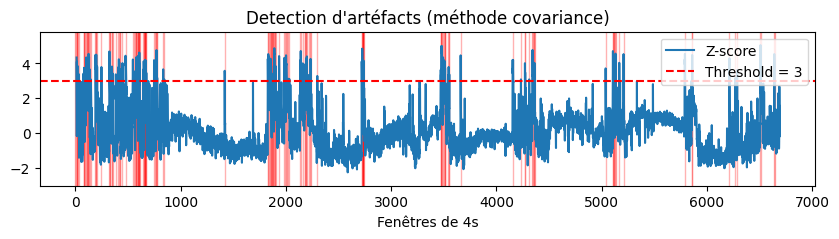

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
plt.plot(zscores, label="Z-score")
plt.axhline(3, color='r', linestyle='--', label='Threshold = 3')
plt.fill_between(range(len(art)), 0, 1, where=art, color='red', alpha=0.3, transform=plt.gca().get_xaxis_transform())
plt.legend()
plt.title("Detection d'artéfacts (méthode covariance)")
plt.xlabel("Fenêtres de 4s")
plt.show()


In [ ]:
# vérification des fenêtres non valides
print(np.isnan(zscores).sum(), "/", len(zscores), "fenêtres non valides")


12 / 6695 fenêtres non valides


In [14]:
import numpy as np

# Taille de chaque fenêtre en échantillons
win_size = int(sfreq * 4)  # 4 s

# Nombre total de fenêtres
n_windows = len(art)

# Nombre total d’échantillons
n_samples = raw.n_times

# Création d’un masque initial de tous False
valid_mask = np.full(n_samples, False)

# Pour chaque fenêtre non corrompue, on remplit le masque
for i, is_art in enumerate(art):
    if not is_art:  # si pas d'artéfact
        start = i * win_size
        end = min(start + win_size, n_samples)
        valid_mask[start:end] = True


In [15]:
print(valid_mask.shape)  # (n_samples,)
print(np.sum(valid_mask) / len(valid_mask))  # % d’échantillons valides


(6855680,)
0.9505601194921584


In [16]:
# Extraire les données propres
clean_data = data[:, valid_mask]

# Masquer les valeurs corrompues
masked_data = np.copy(data)
masked_data[:, ~valid_mask] = np.nan

# Combiner avec d'autres filtres (Ex. REM uniquement)
rem_mask = hypno_array == 4
rem_clean_mask = valid_mask & rem_mask
rem_clean_data = data[:, rem_clean_mask]


/tmp/ipykernel_3739/3531523576.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/darryld/Bureau/Cerco_studies/.env_REM_Cerco/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


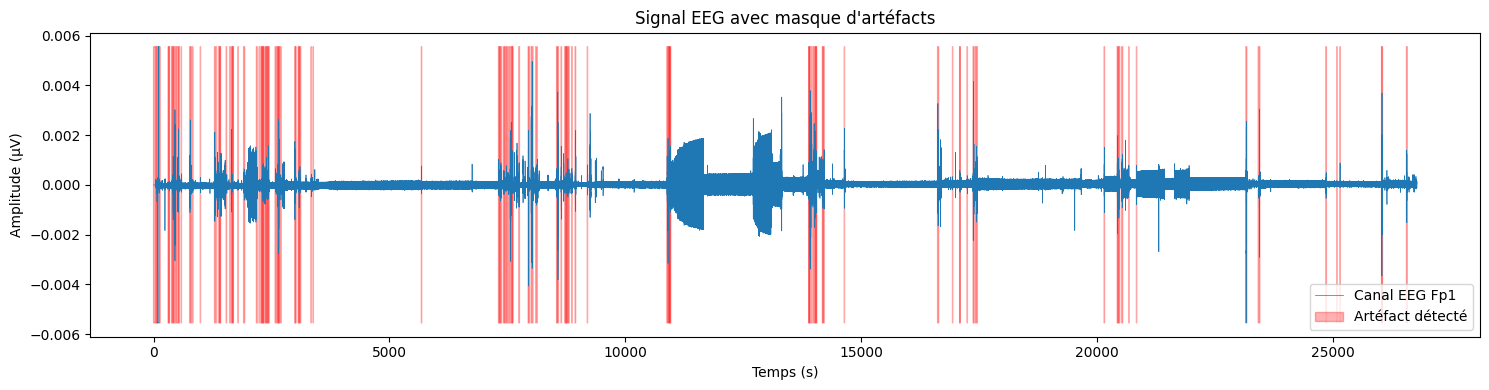

In [17]:
import matplotlib.pyplot as plt

# Choix du canal à afficher (ex. Fz ou canal 0)
ch = 0
eeg = data[ch, :]  # signal du canal

# Génération d’un vecteur temps en secondes
times = np.arange(eeg.size) / sfreq

# Plot
plt.figure(figsize=(15, 4))
plt.plot(times, eeg, label=f"Canal {chan[ch]}", linewidth=0.5)

# Marquage des zones avec artéfacts (valid_mask == False)
plt.fill_between(times, eeg.min(), eeg.max(), where=~valid_mask, color='red', alpha=0.3, label="Artéfact détecté")

plt.title("Signal EEG avec masque d'artéfacts")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.tight_layout()
plt.show()
